In [1]:
import librosa
import librosa.display

import matplotlib.pyplot as plt

import numpy as np

from IPython.display import Audio

In [2]:
noisy_audio, sr = librosa.load(
    "input/noisy.wav",
    sr=16000
)

denoised_audio, sr = librosa.load(
    "output/noisy.wav",
    sr=16000
)

print("Loaded successfully")

Loaded successfully


In [3]:
Audio(noisy_audio, rate=sr)

In [4]:
Audio(denoised_audio, rate=sr)

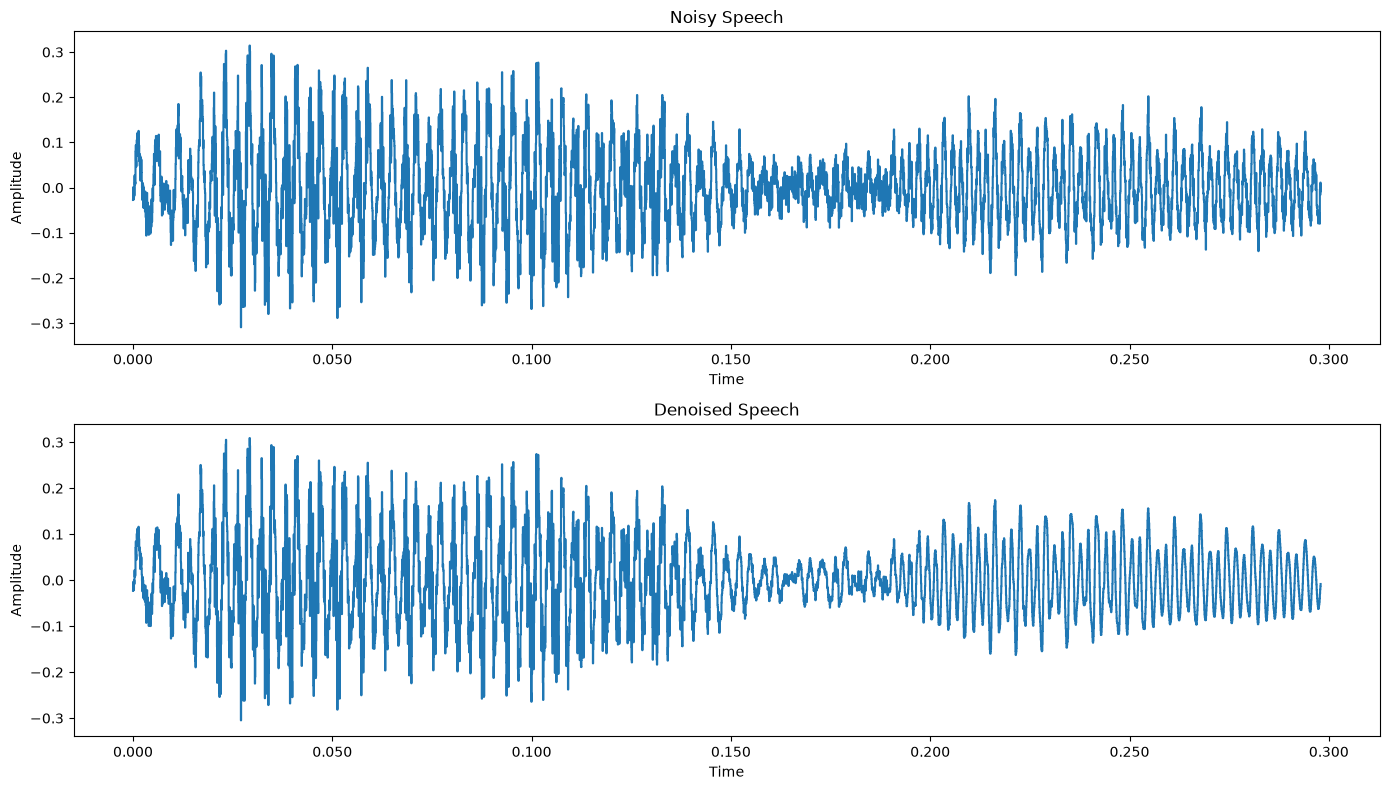

In [5]:
plt.figure(figsize=(14,8))

plt.subplot(2,1,1)

librosa.display.waveshow(
    noisy_audio,
    sr=sr
)

plt.title("Noisy Speech")

plt.xlabel("Time")

plt.ylabel("Amplitude")

plt.subplot(2,1,2)

librosa.display.waveshow(
    denoised_audio,
    sr=sr
)

plt.title("Denoised Speech")

plt.xlabel("Time")

plt.ylabel("Amplitude")

plt.tight_layout()

plt.show()

In [6]:
plt.savefig("output/waveform_comparison.png")

<Figure size 640x480 with 0 Axes>

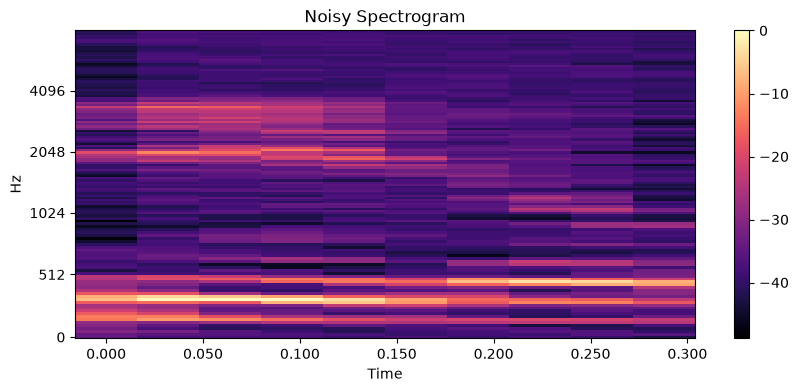

In [7]:
mel = librosa.feature.melspectrogram(
    y=noisy_audio,
    sr=sr
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Noisy Spectrogram")

plt.savefig("output/noisy_spectrogram.png")

plt.show()

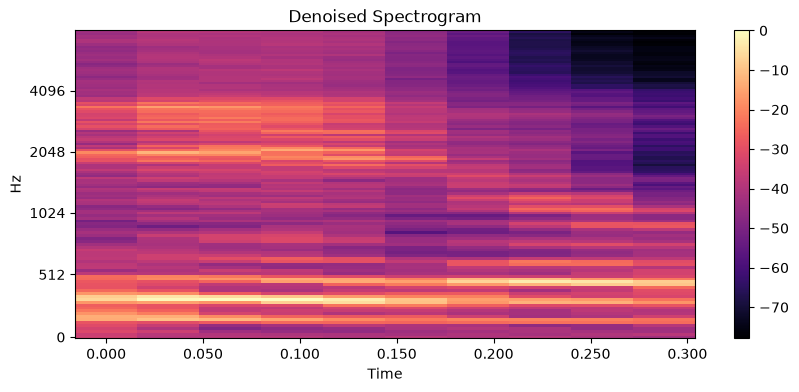

In [8]:
mel = librosa.feature.melspectrogram(
    y=denoised_audio,
    sr=sr
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Denoised Spectrogram")

plt.savefig("output/denoised_spectrogram.png")

plt.show()

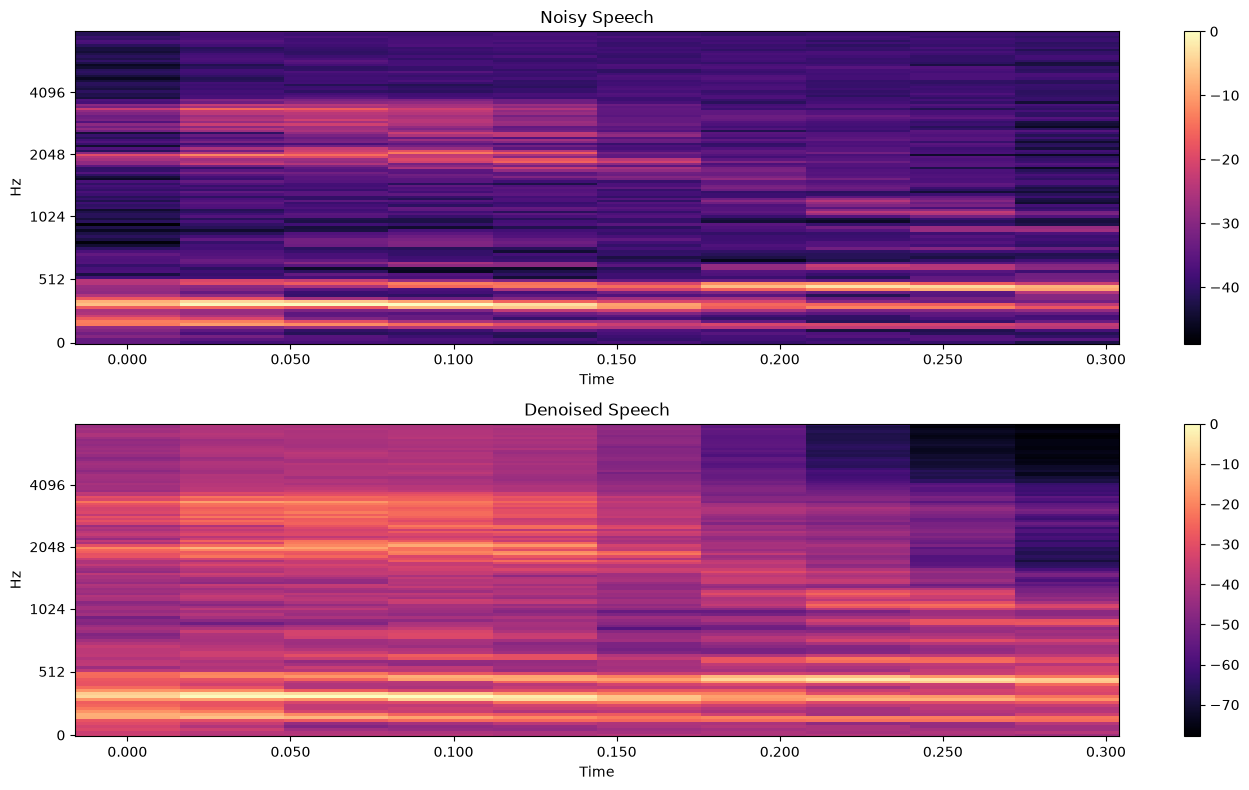

In [9]:
plt.figure(figsize=(14,8))

plt.subplot(2,1,1)

librosa.display.specshow(
    librosa.power_to_db(
        librosa.feature.melspectrogram(
            y=noisy_audio,
            sr=sr
        ),
        ref=np.max
    ),
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.title("Noisy Speech")

plt.colorbar()

plt.subplot(2,1,2)

librosa.display.specshow(
    librosa.power_to_db(
        librosa.feature.melspectrogram(
            y=denoised_audio,
            sr=sr
        ),
        ref=np.max
    ),
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.title("Denoised Speech")

plt.colorbar()

plt.tight_layout()

plt.savefig("output/spectrogram_comparison.png")

plt.show()

In [10]:
print("Sampling Rate :", sr)

print("Noisy Audio Samples :", len(noisy_audio))

print("Denoised Audio Samples :", len(denoised_audio))

Sampling Rate : 16000
Noisy Audio Samples : 4768
Denoised Audio Samples : 4768


Observation:
In this task, a noisy speech recording was processed using the pretrained DTLN speech denoising model. The model successfully reduced the background noise without requiring any additional training. The waveform of the denoised speech appeared smoother than the noisy speech, indicating reduced unwanted signal variations.The Mel spectrogram also showed that many background noise components were suppressed while preserving the important speech information. The denoised audio was clearer and easier to understand compared to the original noisy recording.